# 01-2. Train Moment-Guided Deformable DETR

기존 `gt_aux` 구현은 수정하지 않습니다. 새 `moment_guided_detr` 패키지의 모델을 VOC2007 smoke split으로 학습합니다. Deformable cross-attention의 sampled location/weight에서 query별 1차 모멘트(중심)와 2차 모멘트(공분산)를 계산하며, 이 경로는 학습 또는 명시적인 진단 때만 실행됩니다.

In [1]:
from pathlib import Path
import gc, importlib, json, sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch

ROOT = Path.cwd()
if not (ROOT / 'data').exists() and (Path('D:/gt-super') / 'data').exists():
    ROOT = Path('D:/gt-super')
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import gt_aux.config as config_module
import gt_aux.data as data_module
import moment_guided_detr.artifacts as artifacts_module
import moment_guided_detr.model as model_module
import moment_guided_detr.train as train_module
for module in [config_module, data_module, artifacts_module, model_module, train_module]:
    importlib.reload(module)

ExperimentConfig = config_module.ExperimentConfig
prepare_data = data_module.prepare_data
make_loaders = data_module.make_loaders
MomentTrainingSettings = train_module.MomentTrainingSettings
train_moment_experiment = train_module.train_moment_experiment
release_model = train_module.release_model
make_moment_model = model_module.make_moment_model
checkpoint_path = artifacts_module.checkpoint_path
history_path = artifacts_module.history_path
output_dir = artifacts_module.output_dir
print({'root': str(ROOT), 'torch': torch.__version__, 'device': 'cuda' if torch.cuda.is_available() else 'cpu'})

d:\gt-super\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


{'root': 'd:\\gt-super', 'torch': '2.11.0+cu128', 'device': 'cuda'}


## 1. 고정 실험 설정

기존 baseline과 동일하게 data seed 42, training seed 42/43/44, 400/100 split, 7 epoch를 사용합니다. Moment loss weight는 구조 검증을 명확하게 하기 위해 일정하게 유지합니다.

In [2]:
RUN_MODE = 'smoke'
SEEDS = [42, 43, 44]
DATA_SEED = 42
TRAIN_IMAGES, VAL_IMAGES, EPOCHS = 400, 100, 7
BATCH_SIZE, NUM_WORKERS = 2, 0
IMAGE_MIN_SIZE, IMAGE_MAX_SIZE = 384, 640

MOMENT_WEIGHT = 1.0
CENTER_WEIGHT = 1.0
COVARIANCE_WEIGHT = 1.0
RUN_TRAINING = True
SKIP_COMPLETED = True
AUTO_RESUME_INCOMPLETE = True
RESUME_FROM_BY_SEED = {}

CONFIG = ExperimentConfig.for_run(
    ROOT, run_mode=RUN_MODE, seed=SEEDS[0], data_seed=DATA_SEED,
    experiments=['moment_guided'], train_images=TRAIN_IMAGES, val_images=VAL_IMAGES,
    epochs=EPOCHS, batch_size=BATCH_SIZE, num_workers=NUM_WORKERS,
    image_min_size=IMAGE_MIN_SIZE, image_max_size=IMAGE_MAX_SIZE,
)
SETTINGS = MomentTrainingSettings(
    moment_weight=MOMENT_WEIGHT, center_weight=CENTER_WEIGHT,
    covariance_weight=COVARIANCE_WEIGHT,
)
display(pd.Series({**CONFIG.as_dict(), **SETTINGS.as_dict()}, name='value').to_frame())

,value
root,D:\gt-super
run_mode,smoke
checkpoint,SenseTime/deformable-detr
train_images,400
val_images,100
epochs,7
batch_size,2
num_workers,0
image_size,"{'shortest_edge': 384, 'longest_edge': 640}"
lr,0.0002


## 2. 동일 VOC split 준비

`prepare_data`는 기존 baseline과 같은 selection/split 알고리즘을 사용하고 split manifest를 검증 가능한 형태로 남깁니다.

In [3]:
BUNDLE = prepare_data(CONFIG)
manifest_path = CONFIG.output_dir / 'voc2007_split_manifest.json'
manifest = json.loads(manifest_path.read_text(encoding='utf-8'))
assert manifest['data_seed'] == DATA_SEED
assert len(BUNDLE.train_records) == TRAIN_IMAGES
assert len(BUNDLE.val_records) == VAL_IMAGES
print({
    'train_images': len(BUNDLE.train_records), 'val_images': len(BUNDLE.val_records),
    'train_objects': sum(len(r['boxes_xyxy']) for r in BUNDLE.train_records),
    'val_objects': sum(len(r['boxes_xyxy']) for r in BUNDLE.val_records),
    'data_seed': manifest['data_seed'],
})

VOC XML: 100%|██████████| 3750/3750 [00:01<00:00, 2854.57it/s]


Full split: train=3000 (9180 objects), val=750 (2530 objects)
Current run: train=400, val=100
{'train_images': 400, 'val_images': 100, 'train_objects': 1310, 'val_objects': 311, 'data_seed': 42}


## 3. 한 batch 구조/gradient smoke test

가중치를 갱신하기 전에 (1) wrapper와 detector의 inference 출력 동일성, (2) 추가 파라미터 0개, (3) moment 통계 유한성, (4) sampling offset 및 attention weight로의 gradient 전달을 확인합니다.

In [4]:
probe_loader, _ = make_loaders(CONFIG, BUNDLE, SEEDS[0])
probe_batch = next(iter(probe_loader))
probe_model, initial_fingerprint = make_moment_model(
    CONFIG, SEEDS[0], center_weight=CENTER_WEIGHT, covariance_weight=COVARIANCE_WEIGHT,
)
pixel_values = probe_batch['pixel_values'].to(CONFIG.device)
pixel_mask = probe_batch['pixel_mask'].to(CONFIG.device)
labels = train_module.move_labels_to_device(probe_batch['labels'], CONFIG.device)

probe_model.eval()
with torch.inference_mode():
    direct = probe_model.detector(pixel_values=pixel_values, pixel_mask=pixel_mask)
    wrapped = probe_model(pixel_values=pixel_values, pixel_mask=pixel_mask, labels=None)
logit_diff = float((direct.logits - wrapped['outputs'].logits).abs().max())
box_diff = float((direct.pred_boxes - wrapped['outputs'].pred_boxes).abs().max())
assert logit_diff == 0.0 and box_diff == 0.0
assert probe_model.extra_parameter_count == 0
assert wrapped['moment_executed'] is False

probe_model.train()
probe_model.zero_grad(set_to_none=True)
result = probe_model(
    pixel_values=pixel_values, pixel_mask=pixel_mask, labels=labels,
    moment_weight=MOMENT_WEIGHT,
)
assert result['moment_executed']
assert torch.isfinite(result['loss'])
assert torch.isfinite(result['center_loss']) and torch.isfinite(result['covariance_loss'])
result['loss'].backward()
attention = probe_model.final_cross_attention
offset_grad = float(attention.sampling_offsets.weight.grad.float().norm())
weight_grad = float(attention.attention_weights.weight.grad.float().norm())
assert offset_grad > 0 and weight_grad > 0
probe_report = {
    'fingerprint': initial_fingerprint, 'extra_parameters': probe_model.extra_parameter_count,
    'inference_logit_max_diff': logit_diff, 'inference_box_max_diff': box_diff,
    'main_loss': float(result['main_loss'].detach()),
    'center_loss': float(result['center_loss'].detach()),
    'covariance_loss': float(result['covariance_loss'].detach()),
    'matched_queries': result['matched_queries'],
    'valid_attention_mass': result['moment_stats']['valid_attention_mass'],
    'sampling_offset_grad_norm': offset_grad, 'attention_weight_grad_norm': weight_grad,
}
display(pd.Series(probe_report, name='value').to_frame())
probe_model = release_model(probe_model)
del probe_batch, pixel_values, pixel_mask, labels, result, direct, wrapped
gc.collect()

Loading weights: 100%|██████████| 545/545 [00:00<00:00, 16979.85it/s]
[transformers] DeformableDetrForObjectDetection LOAD REPORT from: SenseTime/deformable-detr
Key                                                            | Status     |                                                                                         
---------------------------------------------------------------+------------+-----------------------------------------------------------------------------------------
model.backbone.model.layer4.0.downsample.1.num_batches_tracked | UNEXPECTED |                                                                                         
model.backbone.model.layer1.0.downsample.1.num_batches_tracked | UNEXPECTED |                                                                                         
model.backbone.model.layer2.0.downsample.1.num_batches_tracked | UNEXPECTED |                                                                                         
mod

,value
fingerprint,c16286f63961237b
extra_parameters,0
inference_logit_max_diff,0.0
inference_box_max_diff,0.0
main_loss,536.449341
center_loss,0.068497
covariance_loss,0.033671
matched_queries,3
valid_attention_mass,0.624344
sampling_offset_grad_norm,12.159423


0

## 4. seed 42/43/44 smoke 학습

완료된 새 체크포인트는 기본적으로 건너뜁니다. 미완료 체크포인트는 `RESUME_FROM_BY_SEED`에 지정하면 optimizer/scheduler/RNG 상태까지 이어서 학습합니다. 기존 baseline 파일은 읽거나 덮어쓰지 않습니다.

In [5]:
history_frames = []
if RUN_TRAINING:
    for seed in SEEDS:
        path = checkpoint_path(CONFIG, seed)
        csv_path = history_path(CONFIG, seed)
        resume_from = RESUME_FROM_BY_SEED.get(seed)
        if path.exists() and csv_path.exists():
            saved = torch.load(path, map_location='cpu', weights_only=False)
            saved_epoch = int(saved.get('epoch', 0))
            del saved
            if SKIP_COMPLETED and saved_epoch >= EPOCHS:
                print(f'[skip] seed={seed}: completed checkpoint {path.name}')
                history_frames.append(pd.read_csv(csv_path))
                continue
            if AUTO_RESUME_INCOMPLETE and resume_from is None and saved_epoch < EPOCHS:
                resume_from = path
                print(f'[auto-resume] seed={seed}: epoch {saved_epoch} -> {EPOCHS}')
        model, history, gradients = train_moment_experiment(
            CONFIG, BUNDLE, seed=seed, settings=SETTINGS,
            save_checkpoint=True, resume_from=resume_from,
        )
        history_frames.append(history)
        model = release_model(model)
else:
    history_frames = [pd.read_csv(history_path(CONFIG, seed)) for seed in SEEDS]

history_df = pd.concat(history_frames, ignore_index=True)
display(history_df.tail(9))

[skip] seed=42: completed checkpoint checkpoint_smoke_moment_guided_seed42.pt
[auto-resume] seed=43: epoch 3 -> 7

===== moment_guided / seed=43 =====


Loading weights: 100%|██████████| 545/545 [00:00<00:00, 16265.32it/s]
[transformers] DeformableDetrForObjectDetection LOAD REPORT from: SenseTime/deformable-detr
Key                                                            | Status     |                                                                                         
---------------------------------------------------------------+------------+-----------------------------------------------------------------------------------------
model.backbone.model.layer4.0.downsample.1.num_batches_tracked | UNEXPECTED |                                                                                         
model.backbone.model.layer1.0.downsample.1.num_batches_tracked | UNEXPECTED |                                                                                         
model.backbone.model.layer2.0.downsample.1.num_batches_tracked | UNEXPECTED |                                                                                         
mod

[resume] loaded D:\gt-super\cache\checkpoints\checkpoint_smoke_moment_guided_seed43.pt; continuing at epoch 4
[phase] training epoch 4/7: 200 batches


moment_guided e4:   0%|          | 0/200 [00:00<?, ?it/s]d:\gt-super\.venv\Lib\site-packages\torch\autograd\graph.py:869: UserWarning: grid_sampler_2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\Context.cpp:164.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass
d:\gt-super\.venv\Lib\site-packages\torch\autograd\graph.py:869: UserWarning: Memory Efficient attention defaults to a non-deterministic algorithm. To explicitly enable determinism call torch.use_deterministic_algorithms(True, warn_only=False). (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\native\transformers\cuda\attention_bac

{'epoch': 4, 'main_loss': 1.8449, 'moment_loss': 0.0947, 'center_loss': 0.0688, 'covariance_loss': 0.0259, 'map': 0.032, 'map50': 0.0551, 'map75': 0.0367}
[phase] training epoch 5/7: 200 batches


...

moment_guided e6:   0%|          | 0/200 [00:00<?, ?it/s]d:\gt-super\.venv\Lib\site-packages\torch\autograd\graph.py:869: UserWarning: grid_sampler_2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\Context.cpp:164.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


{'epoch': 6, 'main_loss': 1.533, 'moment_loss': 0.0745, 'center_loss': 0.054, 'covariance_loss': 0.0205, 'map': 0.0649, 'map50': 0.1147, 'map75': 0.0692}
[phase] training epoch 7/7: 200 batches


moment_guided e7:   0%|          | 0/200 [00:00<?, ?it/s]d:\gt-super\.venv\Lib\site-packages\torch\autograd\graph.py:869: UserWarning: grid_sampler_2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\Context.cpp:164.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


{'epoch': 7, 'main_loss': 1.4671, 'moment_loss': 0.072, 'center_loss': 0.0505, 'covariance_loss': 0.0214, 'map': 0.0727, 'map50': 0.1192, 'map75': 0.0781}


,experiment,seed,data_seed,epoch,model_fingerprint,train_seconds,main_loss,main_bbox_loss,main_giou_loss,moment_loss,...,valid_attention_mass,off_diagonal_abs,predicted_variance,target_variance,moment_weight,map,map50,map75,mar100,val_seconds
15,moment_guided,43,42,7,d1b7a9f86e187c5e,495.520310,1.470959,0.074434,0.234789,0.067698,...,0.902907,0.001461,0.013254,0.019840,1.0,0.056465,0.095593,0.063009,0.360143,6.859636
16,moment_guided,44,42,0,9fffb715f8680daa,0.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,1.0,0.006012,0.015136,0.003464,0.055678,5.519096
17,moment_guided,44,42,1,9fffb715f8680daa,53.172133,34.980547,0.176989,0.422357,0.110554,...,0.801049,0.002240,0.007266,0.019905,1.0,0.010863,0.022878,0.009452,0.136309,5.305674
18,moment_guided,44,42,2,9fffb715f8680daa,106.736780,2.076842,0.126930,0.343724,0.096416,...,0.851455,0.001384,0.007624,0.019210,1.0,0.018036,0.036376,0.013791,0.178546,5.313844
19,moment_guided,44,42,3,9fffb715f8680daa,225.805540,1.956254,0.116585,0.332598,0.092497,...,0.857235,0.001387,0.008375,0.018539,1.0,0.023357,0.041058,0.022779,0.196250,26.630479
20,moment_guided,44,42,4,9fffb715f8680daa,659.525006,1.797160,0.102095,0.301351,0.095475,...,0.858619,0.001835,0.011673,0.019659,1.0,0.023697,0.046485,0.020133,0.281039,27.845910
21,moment_guided,44,42,5,9fffb715f8680daa,1090.247631,1.626909,0.087848,0.267525,0.085339,...,0.838787,0.001837,0.012007,0.019113,1.0,0.055192,0.091645,0.059020,0.345053,29.928658
22,moment_guided,44,42,6,9fffb715f8680daa,1527.791367,1.532978,0.080593,0.247924,0.074548,...,0.854204,0.001350,0.012976,0.019222,1.0,0.064943,0.114699,0.069227,0.375047,21.641432
23,moment_guided,44,42,7,9fffb715f8680daa,1959.605628,1.467092,0.075681,0.237547,0.071980,...,0.853970,0.001244,0.012155,0.019653,1.0,0.072732,0.119159,0.078083,0.400344,29.819549


## 5. 학습 완료 요약

세 seed의 validation curve와 moment loss가 감소하는지 빠르게 확인합니다. 상세 baseline 비교는 `09_evaluate_moment_guided.ipynb`에서 현재 checkpoint를 직접 재평가합니다.

,seed,map,map50,map75,mar100,center_loss,covariance_loss
7,42,0.0695,0.1220,0.0725,0.3857,0.0434,0.0224
15,43,0.0565,0.0956,0.0630,0.3601,0.0470,0.0207
23,44,0.0727,0.1192,0.0781,0.4003,0.0505,0.0214


,map,map50,map75,mar100,center_loss,covariance_loss
mean,0.0662,0.1122,0.0712,0.3821,0.0470,0.0215
std,0.0086,0.0145,0.0076,0.0203,0.0036,0.0009


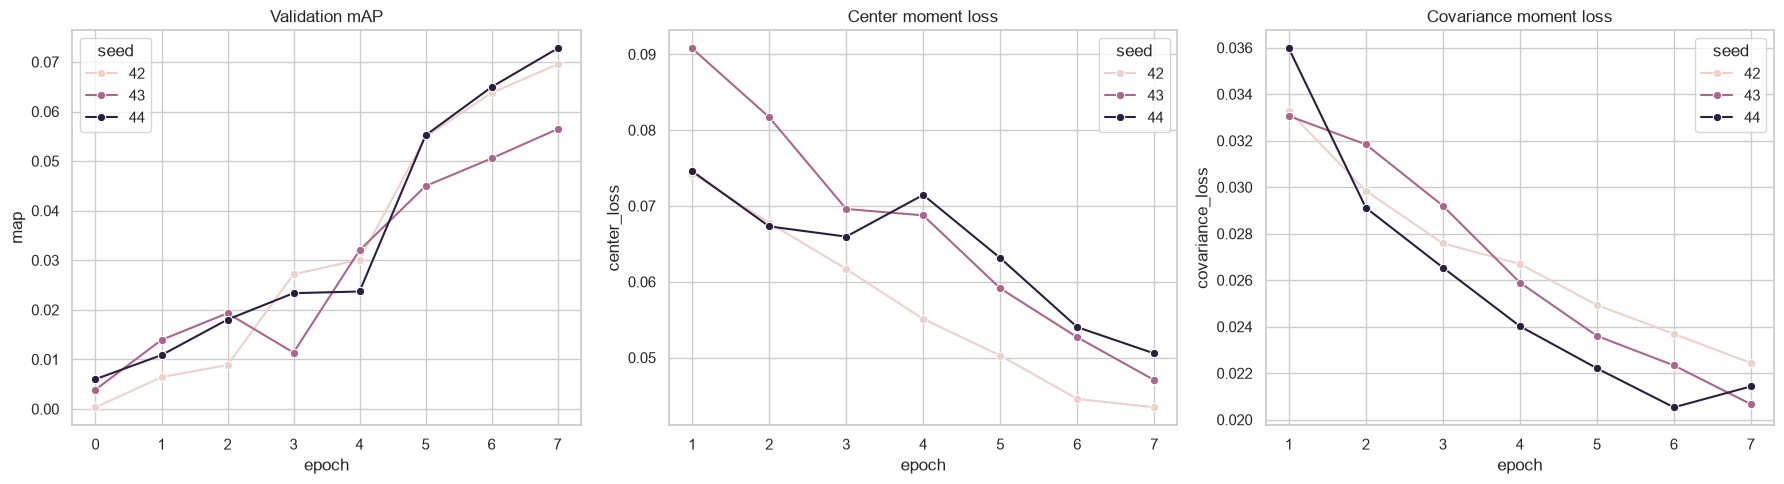

Saved: D:\gt-super\outputs\moment_guided_detr\smoke_training_summary.png
Checkpoints: ['D:\\gt-super\\cache\\checkpoints\\checkpoint_smoke_moment_guided_seed42.pt', 'D:\\gt-super\\cache\\checkpoints\\checkpoint_smoke_moment_guided_seed43.pt', 'D:\\gt-super\\cache\\checkpoints\\checkpoint_smoke_moment_guided_seed44.pt']


In [6]:
final_df = history_df.sort_values('epoch').groupby('seed', as_index=False).tail(1)
summary = final_df[['seed', 'map', 'map50', 'map75', 'mar100', 'center_loss', 'covariance_loss']]
display(summary.style.format({c: '{:.4f}' for c in summary.columns if c != 'seed'}))
display(summary.drop(columns='seed').agg(['mean', 'std']).style.format('{:.4f}'))

sns.set_theme(style='whitegrid')
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for metric, axis, title in zip(
    ['map', 'center_loss', 'covariance_loss'], axes,
    ['Validation mAP', 'Center moment loss', 'Covariance moment loss'],
):
    sns.lineplot(data=history_df, x='epoch', y=metric, hue='seed', marker='o', ax=axis)
    axis.set_title(title)
plt.tight_layout()
figure_path = output_dir(CONFIG) / 'smoke_training_summary.png'
fig.savefig(figure_path, dpi=180, bbox_inches='tight')
plt.show()
print('Saved:', figure_path)
print('Checkpoints:', [str(checkpoint_path(CONFIG, seed)) for seed in SEEDS])